In [ ]:
# ------- [Import all relevant libraries] -------

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Usual Suspects
import numpy as np           # Mathematical operations
import pandas as pd          # Data manipulation

# Visualization
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns

# String manipulation
import re

# Mathematical Operations
import math

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# ML
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, 
    StratifiedKFold, cross_val_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ML Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, make_scorer, f1_score, 
    ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, 
    roc_auc_score, classification_report,
)

import optuna

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_colwidth', None)
from IPython.display import display

# MODELING

We will develop predictive models for H1N1 Vaccine Uptake and Seasonal Flu Vaccine Uptake independently.  
To ensure methodological rigor, the modeling workflow will proceed in three structured phases:

1. Baseline Modeling (Vanilla Iteration): We begin by training all selected classifiers using their default hyperparameters. This establishes foundational performance benchmarks, providing a reference point for evaluating subsequent enhancements.
2. Addressing Class Imbalance: Univariate exploration in the EDA phase revealed a significant imbalance in the target variable distributions. To mitigate this, techniques such as **class weighting** and **SMOTE oversampling** will be applied. Models will then be retrained to assess improvements in sensitivity to the minority class.
3. Hyperparameter Optimization: Once the strongest initial performers are identified, we will conduct targeted hyperparameter tuning to maximize predictive power, stability, and generalization capability.

#### Selected Classifiers

To capture a broad spectrum of learning behaviors, the following algorithms will be employed:

- **Logistic Regression** – Provides strong interpretability and serves as a robust linear baseline.  
- **Decision Trees** – Captures hierarchical, rule-based relationships.  
- **Random Forest** – Handles non-linearity and feature interactions effectively.  
- **XGBoost** – A high-performance boosting algorithm well suited for structured data.  
- **CatBoost** – Optimized for categorical variables with strong default performance.  
- **Neural Networks** – Capable of modelling complex, non-linear feature interactions.

This selection offers a balanced blend of interpretability, flexibility, and predictive strength.

## DATA PREPARATION

Prior to training, the dataset will undergo the following preprocessing procedures:

- Separate the target variable from the feature set.  
- Encode categorical features using appropriate techniques (e.g., one-hot, ordinal, or CatBoost encoding).  
- Scale numerical variables to ensure model stability and comparability.  
- Conduct a multicollinearity assessment using **Variance Inflation Factor (VIF)**.  
- Remove redundant or highly correlated features based on VIF outcomes.

In [26]:
# Create a copy to avoid modifying original
data = pd.read_csv("../Data/modeling_data.csv")

# Create a copy
df = data.copy(deep=True)

# --- IDE ---

# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check columns
print('\n'+'=='*44)
print("Columns:")
display(df.columns)

# Check metadata
print('\n'+'=='*44)
print("Metadata Check:")
display(df.info())

# Check and remove duplicates
print('\n'+'=='*44)
print("Duplicates:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)
print("Duplicates after dropping:", df.duplicated().sum())

# Check data completeness
print('\n'+'=='*44)
print("Missingness check:")
display(df.isna().sum())

The dataset has 26707 rows and 34 columns.

Columns:


Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'h1n1_vaccine',
       'seasonal_vaccine'],
      dtype='object')


Metadata Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26707 non-null  float64
 1   h1n1_knowledge               26707 non-null  float64
 2   behavioral_antiviral_meds    26707 non-null  float64
 3   behavioral_avoidance         26707 non-null  float64
 4   behavioral_face_mask         26707 non-null  float64
 5   behavioral_wash_hands        26707 non-null  float64
 6   behavioral_large_gatherings  26707 non-null  float64
 7   behavioral_outside_home      26707 non-null  float64
 8   behavioral_touch_face        26707 non-null  float64
 9   doctor_recc_h1n1             26707 non-null  float64
 10  doctor_recc_seasonal         26707 non-null  float64
 11  chronic_med_condition        26707 non-null  float64
 12  child_under_6_months         26707 non-null  float64
 13 

None


Duplicates: 1
Duplicates after dropping: 0

Missingness check:


h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
hhs_geo_region                 0
census_msa                     0
household_

We will start by predicting H1N1 Vaccine

In [27]:
# ------- [PREPROCESSING PIPELINE] -------

# Separate features and target
X = df.drop('h1n1_vaccine', axis=1)
y = df['h1n1_vaccine']

# Identify feature types
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# Fit pipeline
X_processed = preprocessor.fit_transform(X)

# Extract transformed column names
encoded_cat_cols = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
processed_feature_names = num_cols + list(encoded_cat_cols)

# Convert to DataFrame
df_processed = pd.DataFrame(X_processed, columns=processed_feature_names)

# Compute VIF
df_vif = df_processed.copy()
df_vif['intercept'] = 1 

vif_df = pd.DataFrame({
    'feature': df_vif.columns,
    'VIF': [
        variance_inflation_factor(df_vif.values, i)
        for i in range(df_vif.shape[1])
    ]
})

display(vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True))

,feature,VIF
0,intercept,54.854154
1,education_Graduate,4.222907
2,education_Some College,3.303439
3,education_HS Grad,2.862226
4,age_group_65+,2.860089
5,hhs_geo_region_lzgpxyit,2.678592
6,race_White,2.614961
7,hhs_geo_region_fpwskwrf,2.356300
8,hhs_geo_region_qufhixun,2.258785
9,hhs_geo_region_bhuqouqj,2.188467


## VANILLA MODELS

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.852322,0.852303,0.842773,0.842374,0.852322,0.852303,0.843887,0.842781,0.873484,0.864854
1,Random Forest,1.000000,0.851741,1.000000,0.841525,1.000000,0.851741,1.000000,0.838764,1.000000,0.860071
2,XGBoost,0.936248,0.844253,0.935219,0.834494,0.936248,0.844253,0.934387,0.836793,0.974230,0.861784
3,Gradient Boosting,0.856815,0.854736,0.848444,0.845857,0.856815,0.854736,0.849867,0.847189,0.884956,0.871390


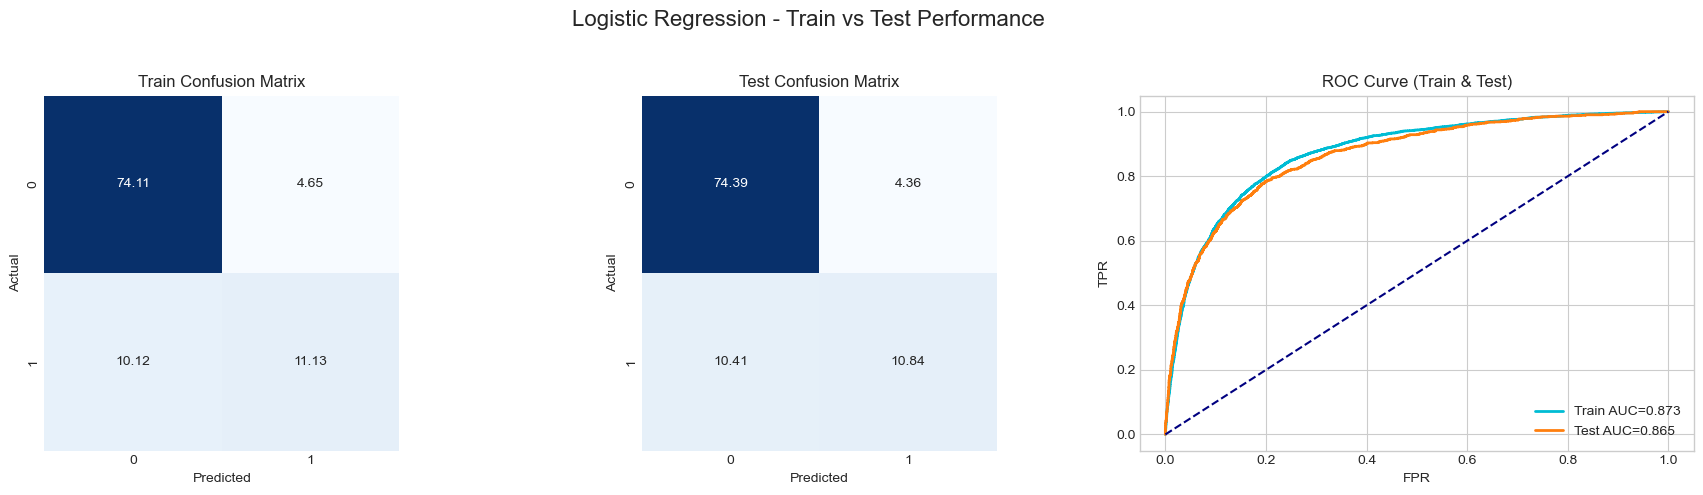

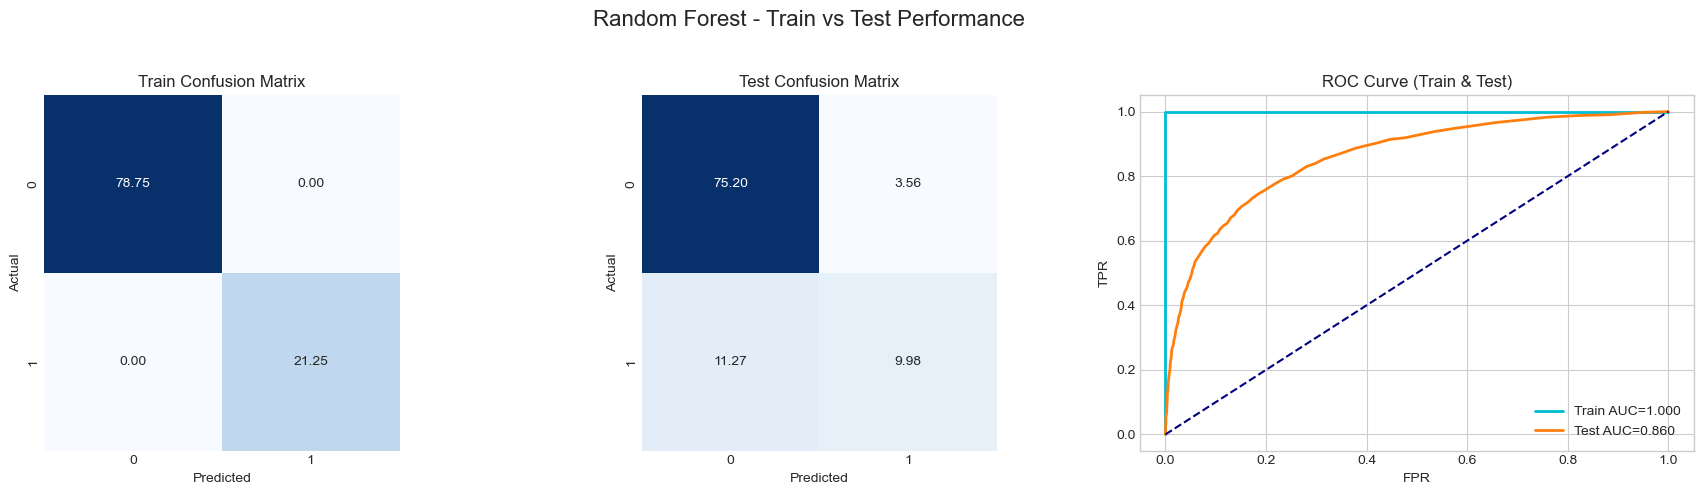

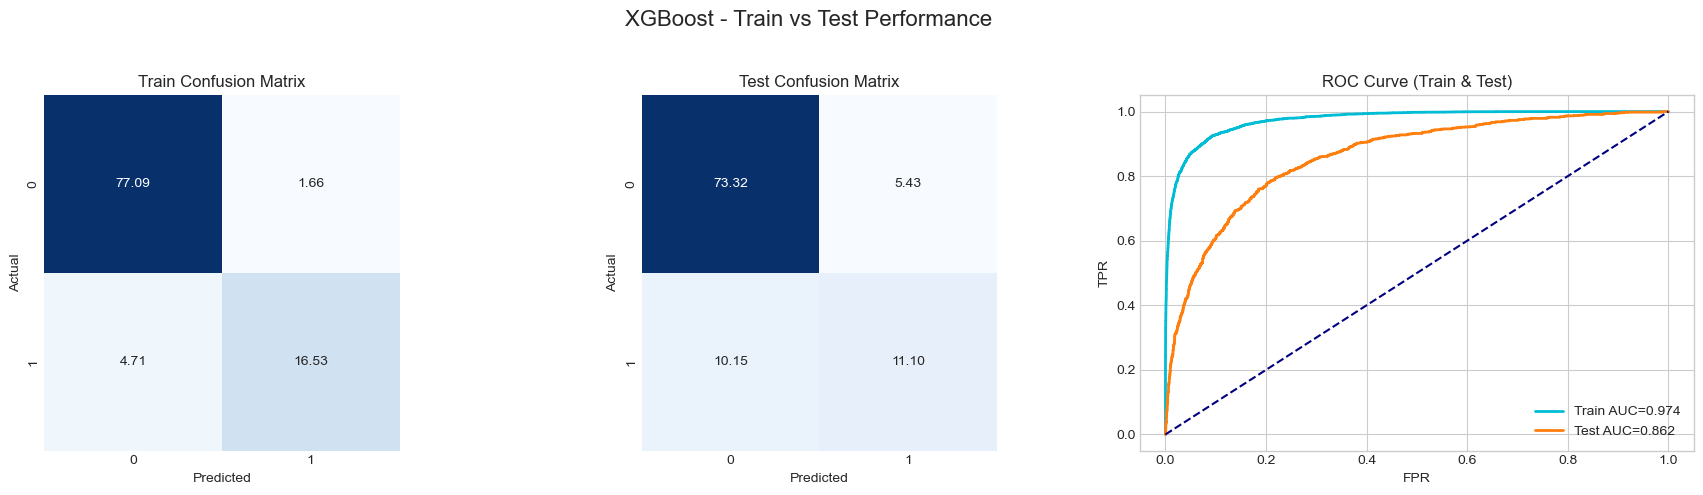

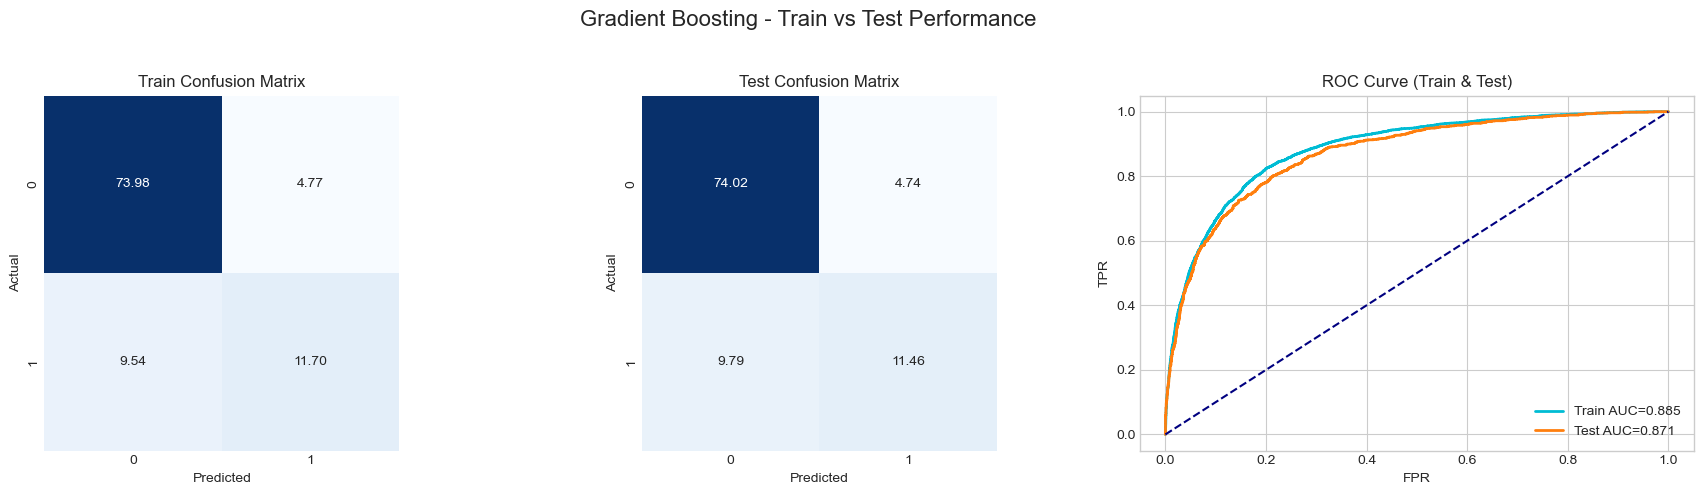

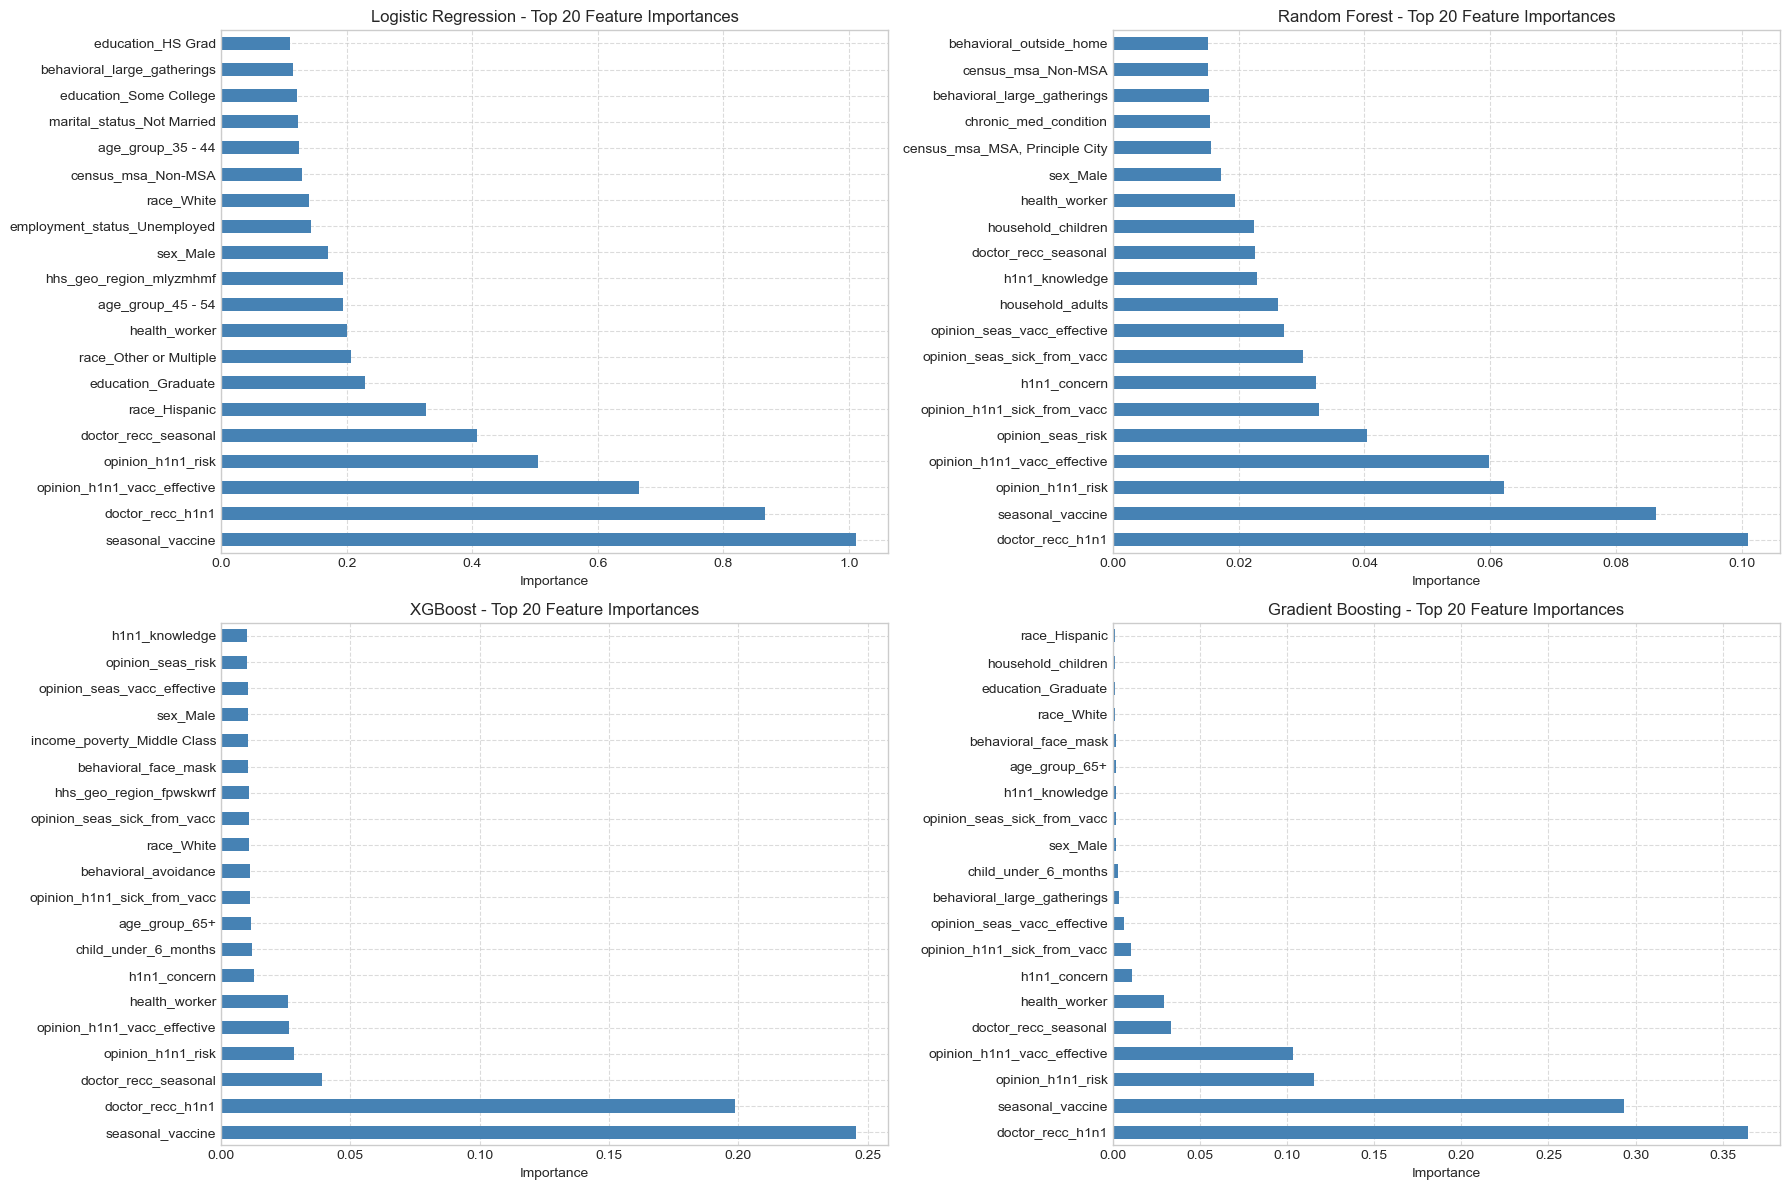

In [ ]:
# PIPELINE-BASED MODEL TRAINING & EVALUATION

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)


# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models and store metrics
for name, clf in models.items():

    # Pipeline with preprocessing
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)

    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred

    # Compute metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # Save top 20 feature importances
    final_model = pipeline.named_steps['model']
    try:
        if hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=df_processed.columns).sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=df_processed.columns).sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(df_processed.columns), index=df_processed.columns)
    except:
        importances = pd.Series([0]*len(df_processed.columns), index=df_processed.columns)
    
    feature_importances[name] = importances


# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)


# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance", fontsize=16)
    
    # Confusion matrices as percentages
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    # Combined ROC
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## DEALING WITH CLASS IMBALANCE

### 1. USING CLASS WEIGHTS

In [29]:
# # ---------------------------------------------------------
# # VANILLA BASELINE MODELS USING THE PREPROCESSOR PIPELINE
# # ---------------------------------------------------------

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import pandas as pd

# # ---------------------------------------
# # Train-test split
# # ---------------------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # ---------------------------------------
# # Define vanilla models
# # ---------------------------------------
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
#     "Decision Tree": DecisionTreeClassifier(random_state=42),
#     "Random Forest": RandomForestClassifier(random_state=42),
#     "XGBoost": XGBClassifier(
#         use_label_encoder=False,
#         eval_metric="logloss",
#         verbosity=0,
#         random_state=42
#     ),
#     "CatBoost": CatBoostClassifier(
#         verbose=0,
#         random_state=42
#     )
# }

# # ---------------------------------------
# # Train + Evaluate all models
# # ---------------------------------------
# results = []

# for name, model in models.items():
    
#     pipeline = Pipeline(steps=[
#         ("preprocess", preprocessor),
#         ("model", model)
#     ])
    
#     pipeline.fit(X_train, y_train)
#     preds = pipeline.predict(X_test)
    
#     results.append({
#         "Model": name,
#         "Accuracy": accuracy_score(y_test, preds),
#         "Precision": precision_score(y_test, preds),
#         "Recall": recall_score(y_test, preds),
#         "F1 Score": f1_score(y_test, preds)
#     })

# results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
# display(results_df)